In [4]:
import numpy as np
from pathlib import Path
import cv2
import math
import matplotlib as plt 
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
import pandas as pd

# Charger le fichier
df = pd.read_csv("mission_data.csv")

# Vérifier
df.head()

ModuleNotFoundError: No module named 'pandas'

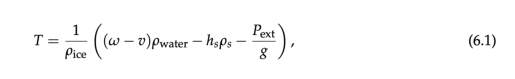

In [3]:
save = "/Users/semita/Desktop/polaris/"
image = plt.imread(save + "equation.png")
plt.imshow(image)
plt.axis("off")  # Hide axes
plt.title("")
plt.show()

In [4]:
# Physical constants (typical values)
rho_ice = 917       # kg/m^3  (sea ice density)
rho_water = 1000    # kg/m^3  (seawater density)
g = 9.81            # m/s^2   (gravitational acceleration)
P_ext = 0           # Pa (external pressure offset — set to 0 if unknown)

In [5]:
def ice_thickness(omega, pressure_bar,  pitch_deg, roll_deg, h_s =0.2,P_ext =0,  rho_s = 300, rho_water = 1000, rho_ice = 917,  g=9.81):
    """
    Parameters:
        omega (float):  distance from vehicle to ice
        v (float):  Distance from water level to pressure sensor
        h_s (float): Snow thickness
        P_ext (float): External pressure offset
    """
    P = (pressure_bar - 1) * 100000  # convert bar → Pa
    v = P / (rho_water * g)

    sensor_offset = 0.05 
     # ---- Correct depth to sonar position
    v_sonar = v + sensor_offset

    omega_corr = omega * np.cos(np.deg2rad(pitch_deg)) * np.cos(np.deg2rad(roll_deg))


    # --- Combine masks
    valid_mask = (np.abs(pitch_deg) <= 25) & (np.abs(roll_deg) <= 10)

    T = (1 / rho_ice) * ((omega_corr - v_sonar) * rho_water - h_s * rho_s - P_ext / g)

    # --- Apply threshold (set invalid to NaN)
    T = np.where(valid_mask, T, np.nan)
    
    return T

In [1]:
def ice_thickness_new(omega, pressure_bar,  pitch_deg, roll_deg, h_s =0.2,P_ext =0,  rho_s = 300, rho_water = 1000, rho_ice = 917,  g=9.81):
    """
    Parameters:
        omega (float):  distance from vehicle to ice
        v (float):  Distance from water level to pressure sensor
        h_s (float): Snow thickness
        P_ext (float): External pressure offset
    """
    P = (pressure_bar - 1) * 100000  # convert bar → Pa
    v = P / (rho_water * g)

    sensor_offset = 0.05 
     # ---- Correct depth to sonar position
    v_sonar = v + sensor_offset

    omega_corr = omega * np.cos(np.deg2rad(pitch_deg)) * np.cos(np.deg2rad(roll_deg))

    attitude_mask = (np.abs(pitch_deg) <= 25) & (np.abs(roll_deg) <= 10)

    # --- Geometric validity (sonar must see ice above vehicle)
    geometry_mask = omega_corr > v_sonar

    # --- Combine masks
    valid_mask = attitude_mask & geometry_mask

    T = (1 / rho_ice) * ((omega_corr - v_sonar) * rho_water - h_s * rho_s - P_ext / g)

    # --- Apply threshold (set invalid to NaN)
    T = np.where(valid_mask, T, np.nan)
    
    return T

In [2]:
df["ice_thickness"] = ice_thickness(
    omega=df["dist_to_ice_m"],
    pressure_bar=df["pressure_bar"],
    pitch_deg=df["pitch_deg"], 
    roll_deg=df["roll_deg"]
)

df.head(20)

NameError: name 'ice_thickness' is not defined

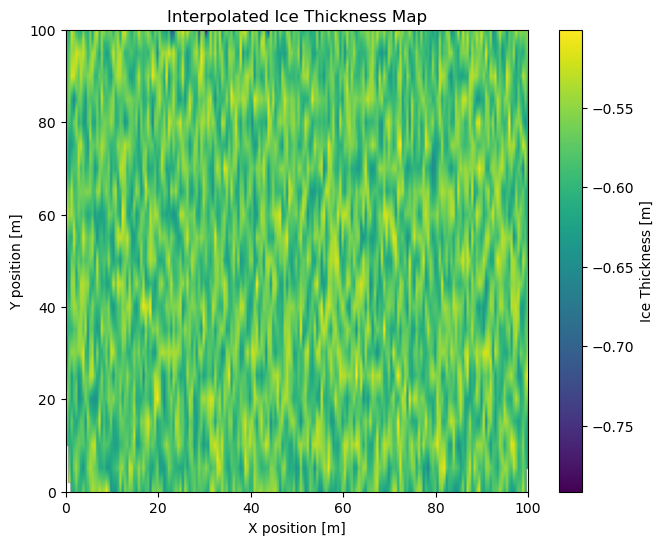

In [8]:
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Remove NaN
df_valid = df.dropna(subset=["ice_thickness"])

# Create grid
grid_x, grid_y = np.mgrid[
    df_valid["x_coord"].min():df_valid["x_coord"].max():200j,
    df_valid["y_coord"].min():df_valid["y_coord"].max():200j
]

# Interpolate
grid_z = griddata(
    (df_valid["x_coord"], df_valid["y_coord"]),
    df_valid["ice_thickness"],
    (grid_x, grid_y),
    method="linear"
)

# Plot
plt.figure(figsize=(8,6))

plt.imshow(
    grid_z.T,
    extent=(df_valid["x_coord"].min(),
            df_valid["x_coord"].max(),
            df_valid["y_coord"].min(),
            df_valid["y_coord"].max()),
    origin='lower',
    cmap="viridis",
    aspect="equal"
)

plt.colorbar(label="Ice Thickness [m]")
plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title("Interpolated Ice Thickness Map")

plt.show()